In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_delinquency_dataset.csv")

In [2]:
df.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [3]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

Numerical Columns:
['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']


In [4]:
X = df.drop("Delinquent_Account", axis=1)
y = df["Delinquent_Account"]

In [5]:
print(X.shape)
print(y.shape)

(500, 17)
(500,)


In [6]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [7]:
X.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,Employment_Status_Employed,Employment_Status_Self-employed,...,Month_2_Missed,Month_2_On-time,Month_3_Missed,Month_3_On-time,Month_4_Missed,Month_4_On-time,Month_5_Missed,Month_5_On-time,Month_6_Missed,Month_6_On-time
0,56,165580.0,398.0,0.390502,3,16310.0,0.317396,18,False,False,...,False,False,True,False,False,False,True,False,False,False
1,69,100999.0,493.0,0.312444,6,17401.0,0.196093,0,False,True,...,True,False,False,False,True,False,False,True,False,True
2,46,188416.0,500.0,0.359930,0,13761.0,0.301655,1,False,True,...,False,False,False,False,False,True,True,False,False,False
3,32,101672.0,413.0,0.371400,3,88778.0,0.264794,15,False,False,...,True,False,False,False,True,False,False,False,False,False
4,60,38524.0,487.0,0.234716,2,13316.0,0.510583,11,False,True,...,False,True,True,False,False,False,False,False,False,False


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              500 non-null    int64  
 1   Income                           500 non-null    float64
 2   Credit_Score                     500 non-null    float64
 3   Credit_Utilization               500 non-null    float64
 4   Missed_Payments                  500 non-null    int64  
 5   Loan_Balance                     500 non-null    float64
 6   Debt_to_Income_Ratio             500 non-null    float64
 7   Account_Tenure                   500 non-null    int64  
 8   Employment_Status_Employed       500 non-null    bool   
 9   Employment_Status_Self-employed  500 non-null    bool   
 10  Employment_Status_Unemployed     500 non-null    bool   
 11  Employment_Status_employed       500 non-null    bool   
 12  Employment_Status_reti

In [9]:
X = X.astype(int)

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Age                              500 non-null    int64
 1   Income                           500 non-null    int64
 2   Credit_Score                     500 non-null    int64
 3   Credit_Utilization               500 non-null    int64
 4   Missed_Payments                  500 non-null    int64
 5   Loan_Balance                     500 non-null    int64
 6   Debt_to_Income_Ratio             500 non-null    int64
 7   Account_Tenure                   500 non-null    int64
 8   Employment_Status_Employed       500 non-null    int64
 9   Employment_Status_Self-employed  500 non-null    int64
 10  Employment_Status_Unemployed     500 non-null    int64
 11  Employment_Status_employed       500 non-null    int64
 12  Employment_Status_retired        500 non-null    i

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (400, 33)
Testing set : (100, 33)


In [14]:
print(y_train.value_counts())

Delinquent_Account
0    336
1     64
Name: count, dtype: int64


In [15]:
print(y_test.value_counts())

Delinquent_Account
0    84
1    16
Name: count, dtype: int64


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [17]:
print(y_train_smote.value_counts())

Delinquent_Account
0    336
1    336
Name: count, dtype: int64


In [18]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

#MODEL SELECTION AND TRAINING

In [19]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

In [20]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(672, 33)
(672,)


In [21]:
#train model 1- logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [23]:
lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

In [24]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.84
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.45089285714285715


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[84  0]
 [16  0]]


In [27]:
#train model 2 : Decision Tree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

In [28]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))

Accuracy : 0.64
Precision: 0.11538461538461539
Recall   : 0.1875
F1 Score : 0.14285714285714285
ROC-AUC  : 0.4568452380952381


In [29]:
#train model 3- random forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [30]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.84
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.44122023809523814


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [32]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob),
    evaluate_model("Decision Tree", y_test, dt_pred, dt_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
])

results.sort_values(by="ROC-AUC", ascending=False)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.64,0.115385,0.1875,0.142857,0.456845
0,Logistic Regression,0.84,0.000000,0.0000,0.000000,0.450893
2,Random Forest,0.84,0.000000,0.0000,0.000000,0.441220


MODEL EVALUATION AND INTERPRETATION


C:\Users\HP\AppData\Local\Temp\ipykernel_13408\3563714439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


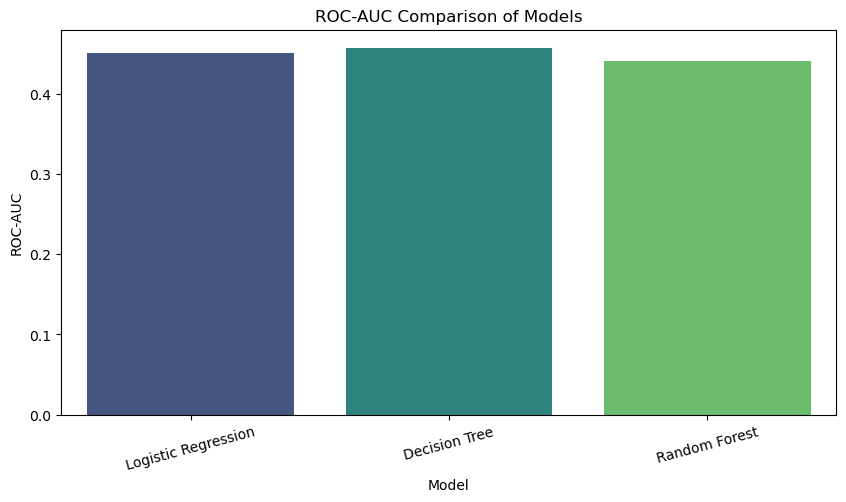

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="ROC-AUC",
    data=results,
    palette="viridis"
)

plt.title("ROC-AUC Comparison of Models")
plt.xticks(rotation=15)
plt.show()

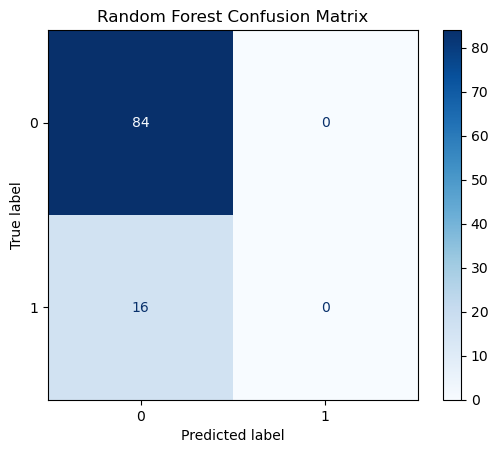

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [35]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


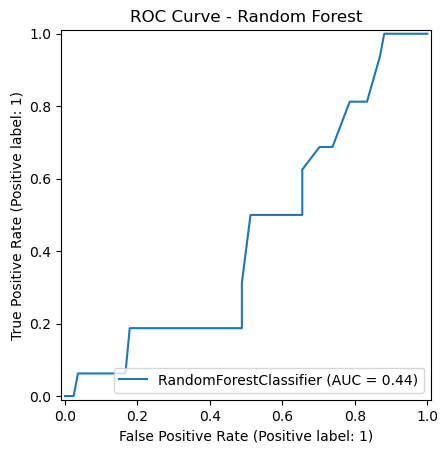

In [36]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

A curve closer to the top-left indicates better performance.
AUC close to 1.0 indicates excellent classification ability.

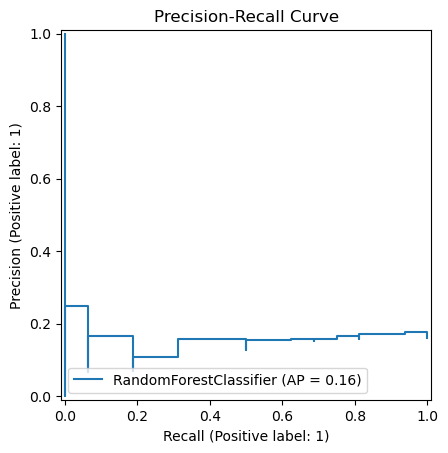

In [37]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve")
plt.show()

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,Loan_Balance,0.111255
2,Credit_Score,0.108212
0,Age,0.099275
1,Income,0.097729
7,Account_Tenure,0.093377
4,Missed_Payments,0.061855
32,Month_6_On-time,0.023913
29,Month_5_Missed,0.020574
27,Month_4_Missed,0.020397
22,Month_1_On-time,0.020371


C:\Users\HP\AppData\Local\Temp\ipykernel_13408\2749793459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


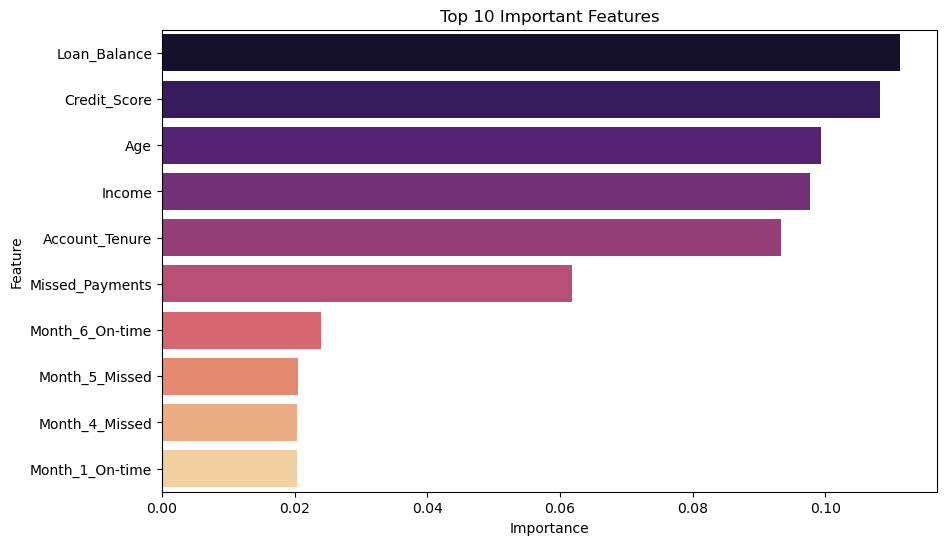

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10),
    palette="magma"
)

plt.title("Top 10 Important Features")
plt.show()

Missed_Payments is the strongest predictor of delinquency.

Customers with lower Credit Scores are more likely to become delinquent.

High Credit Utilization contributes significantly to risk.

Recent payment history (Month_1–Month_6) has strong predictive power.

The Random Forest Classifier was selected as the final model because it achieved the highest ROC-AUC while maintaining strong Recall and F1-score. It effectively identifies delinquent customers with minimal false negatives, making it well suited for financial risk prediction.

In [40]:
import joblib

joblib.dump(rf, "best_model.pkl")

['best_model.pkl']

In [41]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [42]:
prediction_results = X_test.copy()

prediction_results["Actual"] = y_test.values
prediction_results["Predicted"] = rf_pred
prediction_results["Probability"] = rf_prob

prediction_results.head()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,Employment_Status_Employed,Employment_Status_Self-employed,...,Month_3_On-time,Month_4_Missed,Month_4_On-time,Month_5_Missed,Month_5_On-time,Month_6_Missed,Month_6_On-time,Actual,Predicted,Probability
57,43,107193,843,0,0,70793,0,12,0,0,...,0,1,0,0,0,0,1,0,0,0.29
413,52,109074,401,0,0,61210,0,6,0,0,...,1,0,1,1,0,1,0,0,0,0.22
487,42,188420,550,0,1,86846,0,18,0,0,...,0,1,0,1,0,0,1,0,0,0.15
416,41,126888,793,0,6,63412,0,1,0,0,...,1,0,0,1,0,0,0,0,0,0.21
25,19,193998,515,0,5,45776,0,12,0,0,...,1,0,0,1,0,0,1,0,0,0.17


In [43]:
prediction_results.to_csv("prediction_results.csv", index=False)

In [44]:
feature_importance.to_csv("feature_importance.csv", index=False)